In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import warnings
warnings.filterwarnings('ignore')


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e11/sample_submission.csv
/kaggle/input/playground-series-s5e11/train.csv
/kaggle/input/playground-series-s5e11/test.csv


# HW1

In [60]:
# 1) Сформулирована бизнес-постановка задачи - 3 балла

# https://www.kaggle.com/competitions/playground-series-s5e11/overview
''' В рамках данного кагл соревнования нужно предсказать вероятность погашения кредита должником (задача кредитного скоринга) '''

' В рамках данного кагл соревнования нужно предсказать вероятность погашения кредита должником (задача кредитного скоринга) '

In [61]:
# 2) Сформулирована постановка ML-задачи (бинарная классификация) - 2 балла

''' Задача бинарной классификации, метрика соревнований - ROC AUC '''

' Задача бинарной классификации, метрика соревнований - ROC AUC '

In [12]:
# Представлен набор данных, достаточный для решения поставленной задачи - 3 балла

df_train = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
df_test = pd.read_csv('/kaggle/input/playground-series-s5e11/test.csv')
df = pd.concat([df_train,df_test])
share_of_paid = round(df_train.loan_paid_back.value_counts(' ')[1],2)
share_of_not_paid = round(df_train.loan_paid_back.value_counts(' ')[0],2)
df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
254564,848558,92835.97,0.068,744,29704.00,13.48,Female,Single,Bachelor's,Employed,Debt consolidation,B2,NaN
254565,848559,48846.47,0.091,634,20284.33,9.58,Female,Married,High School,Employed,Debt consolidation,D4,NaN
254566,848560,20668.52,0.096,718,26387.55,9.00,Male,Single,Master's,Employed,Debt consolidation,C4,NaN
254567,848561,34105.09,0.094,739,11107.36,9.81,Male,Single,Bachelor's,Employed,Business,C2,NaN


In [73]:
# Предложена метрика - 3 балла
# Присутствует корректное обоснование (включая связь с бизнес-целью/продуктовыми метриками, анализ стоимости ошибок и особенности данных, например, дисбаланс) - 5 баллов

print('''метрика ROC AUC:
 1) Робастная - устойчива к дисбалансу классов (в нашей случае это 20/80)
 2) Бизнесу интересна не просто бинарная метрика (вернет / не вернет), а отранжированная вероятность по каждому клиенту
 3) Интепритируема для бизнеса - (  0.50: "модель не лучше случайного угадывания",
                                    0.70: "приемлемое качество",
                                    0.80: "хорошее качество", 
                                    0.85: "отличное качество для кредитного скоринга",
                                   >0.90: "превосходное качество")
''')



метрика ROC AUC:
 1) Робастная - устойчива к дисбалансу классов (в нашей случае это 20/80)
 2) Бизнесу интересна не просто бинарная метрика (вернет / не вернет), а отранжированная вероятность по каждому клиенту
 3) Интепритируема для бизнеса - (  0.50: "модель не лучше случайного угадывания",
                                    0.70: "приемлемое качество",
                                    0.80: "хорошее качество", 
                                    0.85: "отличное качество для кредитного скоринга",
                                   >0.90: "превосходное качество")



In [64]:
# Рассмотрены базовые характеристики/статистики для набора данных - 3 балла
# Реализованы наиболее релевантные визуализации - 5 баллов
# По ходу работы присутствуют комментарии (вы, как эксперт в предметной области, можете проинтерпретировать полученные результаты анализа, 
#                                             визуализации, расcчитанные статистики, сделав выводы о том, каким образом лучше работать с набором данных в 
#                                             будущем, какие могут возникнуть проблемы, 
#                                             какую предобработку целесообразно сделать и тп). - 6 баллов

df_train.info()
''' - видим, что отсутствуют пустые значения - не нужно будет их заполнять
    - не учитывая колонку id, видим, что у нас 6 колонок с числовыми типами данных и столько же со строковыми (будем их либл декодировать, либо использовать определенные модели, например кэтбуст)
    - всего 593_993 строк в датафрейме и 13 колонок   
'''

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


' - видим, что отсутствуют пустые значения - не нужно будет их заполнять\n    - не учитывая колонку id, видим, что у нас 6 колонок с числовыми типами данных и столько же со строковыми (будем их либл декодировать, либо использовать определенные модели, например кэтбуст)\n    - всего 593_993 строк в датафрейме и 13 колонок   \n'

In [65]:
df_train.nunique()
''' смотрим на количество уникальных значений в каждой колонке, 
    удивляемся, что полов не 2, a 3 (третий = other)
'''

' смотрим на количество уникальных значений в каждой колонке, \n    удивляемся, что полов не 2, a 3 (третий = other)\n'

In [83]:
# можем закодировать данные переменные в числовые, так как в них можно рассмотреть хоть какую то последовательность (мы понимаем, что PhD круче High School и тд)
df['education_level_code'] = df['education_level'].map({
                                                                     'Other' : 1,
                                                               'High School' : 2,
                                                                "Bachelor's" : 3,
                                                                  "Master's" : 4,
                                                                       'PhD' : 5})

df['employment_status_code'] = df['employment_status'].map({
                                                                     'Unemployed' : 1,
                                                                        'Student' : 2,
                                                                  "Self-employed" : 3,
                                                                       "Employed" : 4,
                                                                        'Retired' : 5})

df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,education_level_code,employment_status_code
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,2,3
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,4,4
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,2,4
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,2,4
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254564,848558,92835.97,0.068,744,29704.00,13.48,Female,Single,Bachelor's,Employed,Debt consolidation,B2,NaN,3,4
254565,848559,48846.47,0.091,634,20284.33,9.58,Female,Married,High School,Employed,Debt consolidation,D4,NaN,2,4
254566,848560,20668.52,0.096,718,26387.55,9.00,Male,Single,Master's,Employed,Debt consolidation,C4,NaN,4,4
254567,848561,34105.09,0.094,739,11107.36,9.81,Male,Single,Bachelor's,Employed,Business,C2,NaN,3,4


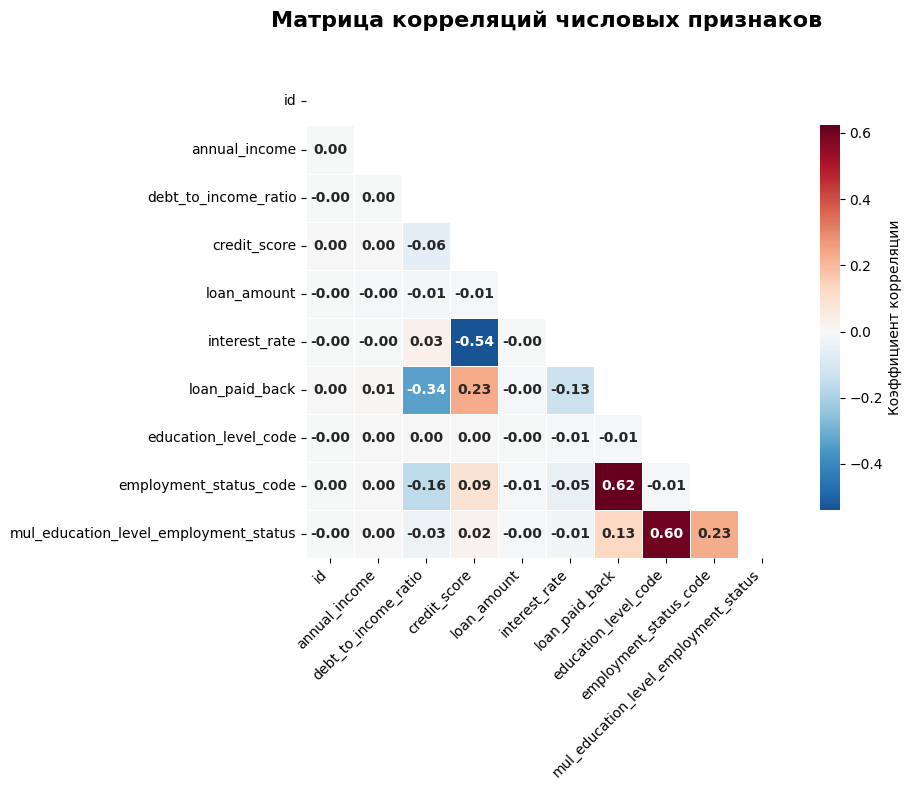

Видим, что для нашего таргета есть 4 переменные с ненулевой корреляцией:
     debt_to_income_ratio   = -0.34
     credit_score           =  0.23
     intereset_rate         = -0.13
     employment_status_code =  0.62



In [81]:

# Создаем красивую тепловую карту корреляций
plt.figure(figsize=(10, 8))

# Вычисляем матрицу корреляций только для числовых колонок
numeric_columns = df_train.select_dtypes(include=[np.number]).columns
correlation_matrix = df_train[numeric_columns].corr()

# Создаем маску для верхнего треугольника
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Создаем тепловую карту с улучшенным дизайном
heatmap = sns.heatmap(correlation_matrix, 
                      mask=mask,
                      annot=True,           # Показывать значения в ячейках
                      fmt=".2f",           # Формат чисел: 2 знака после запятой
                      cmap="RdBu_r",       # Красивая цветовая схема (синий-белый-красный)
                      center=0,            # Центр цветовой шкалы на 0
                      square=True,         # Квадратные ячейки
                      cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"},
                      annot_kws={"size": 10, "weight": "bold"},
                      linewidths=0.5,      # Линии между ячейками
                      linecolor='white')   # Цвет линий

# Настраиваем внешний вид
plt.title('Матрица корреляций числовых признаков\n', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Улучшаем читаемость подписей
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, horizontalalignment='right')
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0)

# Добавляем сетку для лучшей читаемости
plt.grid(False)

# Автоматически подбираем layout
plt.tight_layout()

plt.show()

# Убираем корреляции с самими собой (равные 1)
strong_correlations = corr_pairs[corr_pairs != 1.0].head(10)


print('''Видим, что для нашего таргета есть 4 переменные с ненулевой корреляцией:
     debt_to_income_ratio   = -0.34
     credit_score           =  0.23
     intereset_rate         = -0.13
     employment_status_code =  0.62
''')

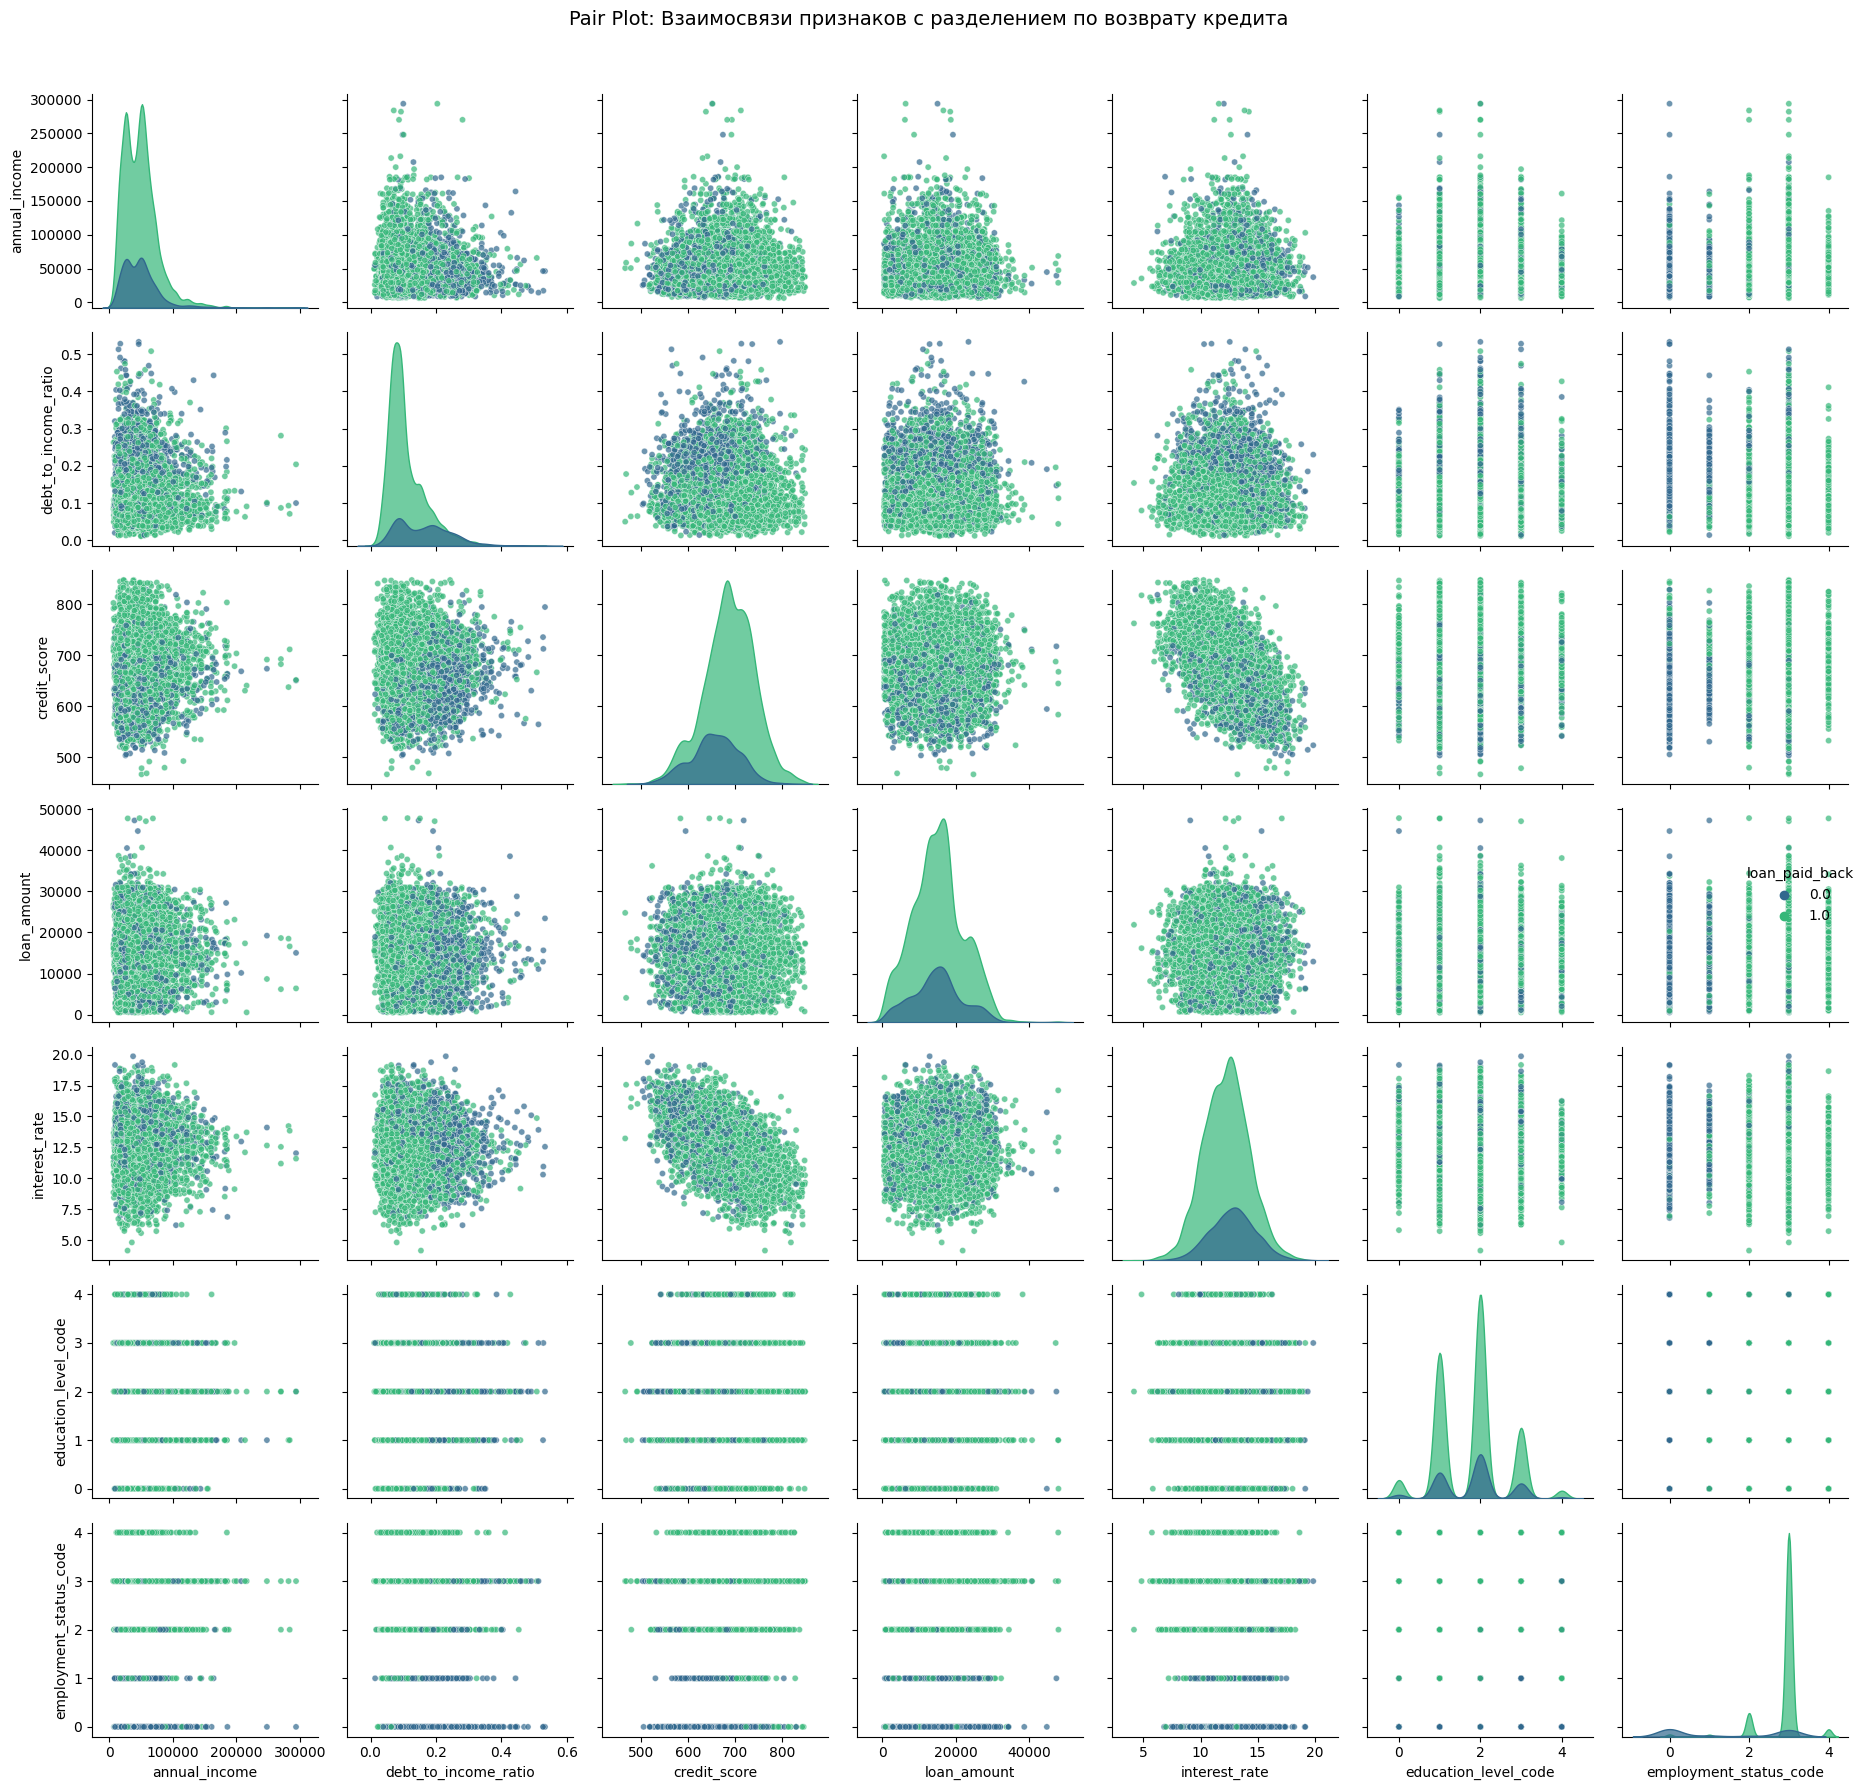

Видим, что "киллер фичей", явно разделяющих наш датасет - нет, однако по некоторым фичам наблюдается некая зависимость, 
например по debt_income_ratio и credit_score

CPU times: user 40.4 s, sys: 21.9 ms, total: 40.5 s
Wall time: 38.3 s


In [68]:
%%time
df_train2 = df_train.head(10_000)
# Строим pairplot, исключая колонку id и используя loan_paid_back для цвета
sns.pairplot(df_train2.drop('id', axis=1), 
             hue='loan_paid_back',
             diag_kind='kde',  # Используем ядерную оценку плотности для диагонали
             palette='viridis', # Цветовая схема
             plot_kws={'alpha': 0.7, 's': 20},  # Прозрачность и размер точек
             diag_kws={'alpha': 0.7})  # Прозрачность для диагональных графиков

plt.suptitle('Pair Plot: Взаимосвязи признаков с разделением по возврату кредита', 
             y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print('''Видим, что "киллер фичей", явно разделяющих наш датасет - нет, 
однако по некоторым фичам наблюдается некая зависимость, 
например по debt_income_ratio и credit_score
''')

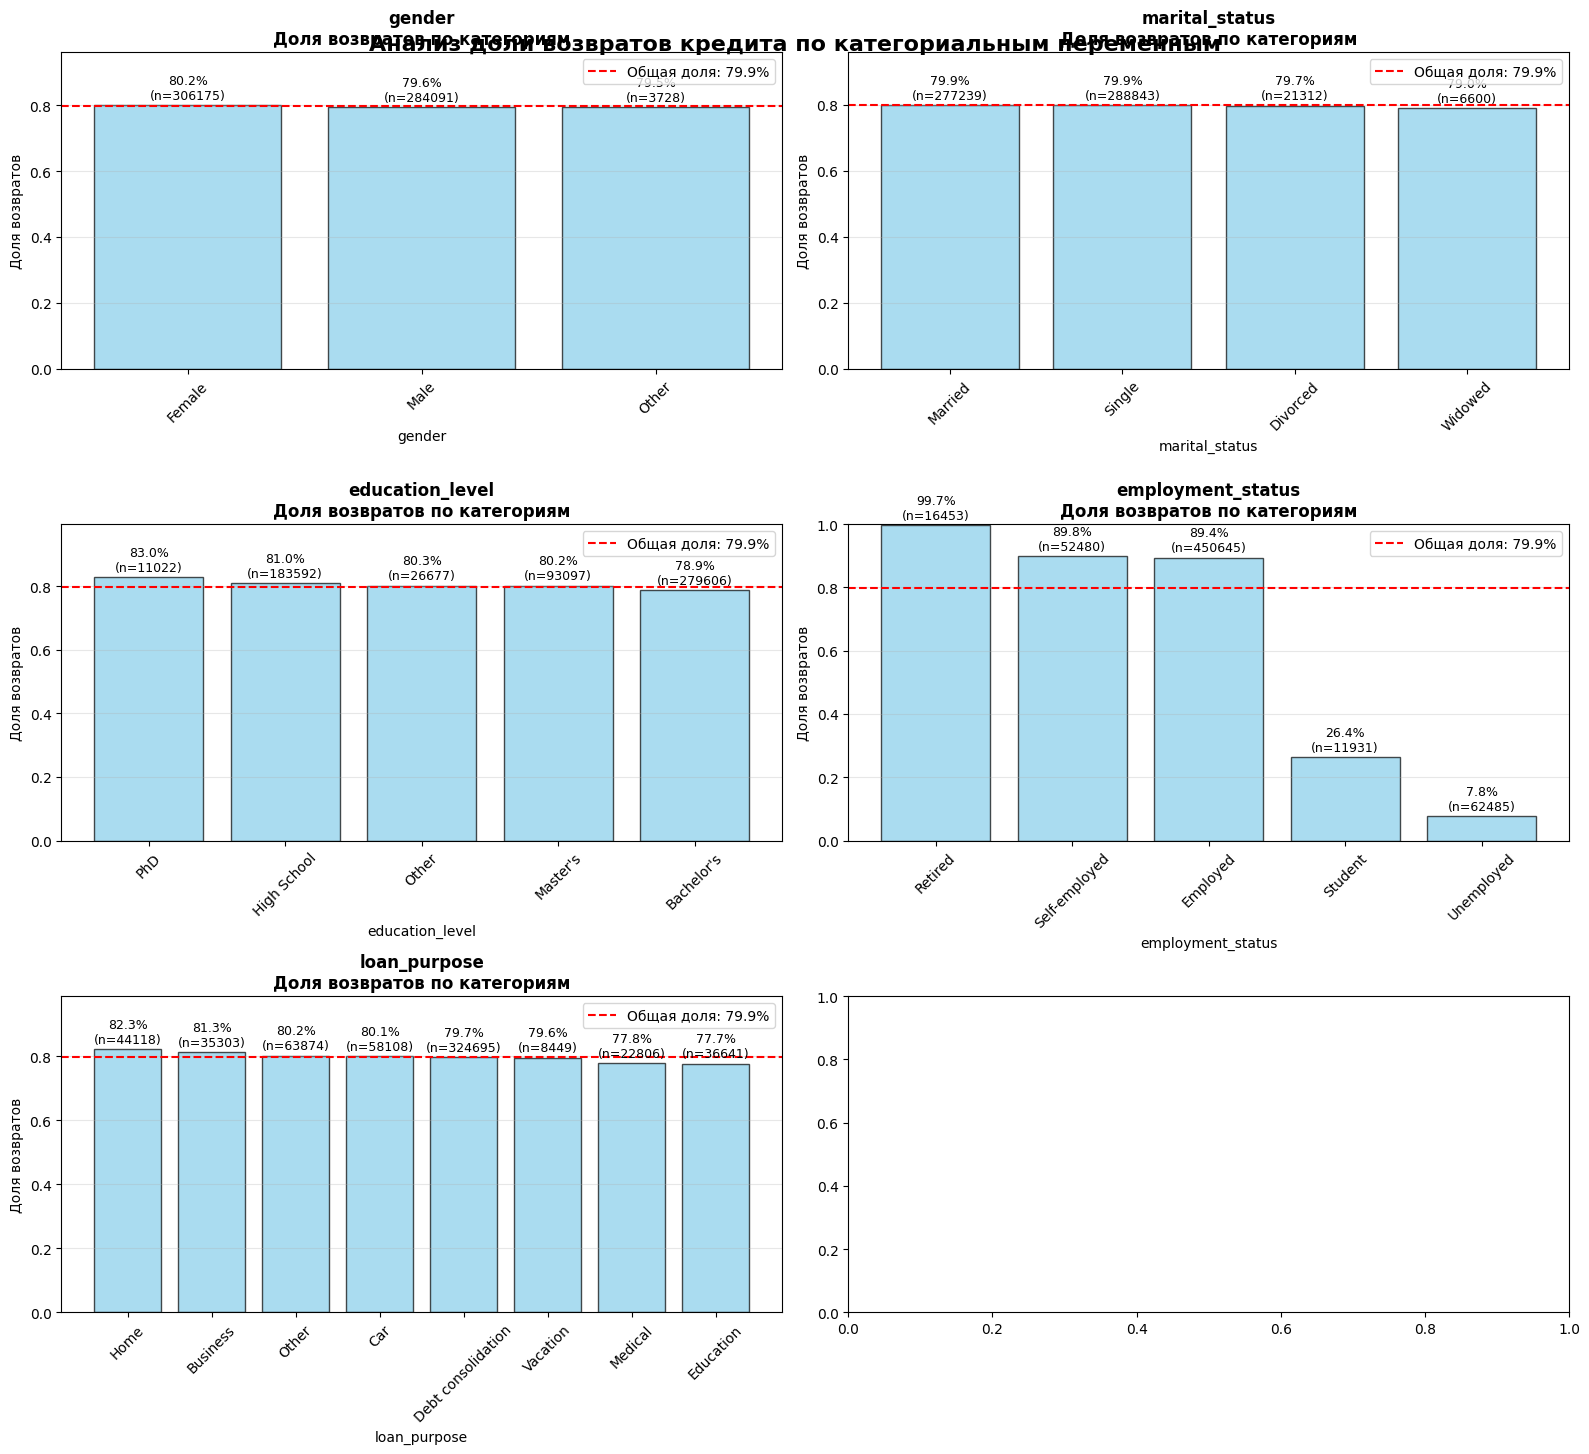

Видим, что в основном процент возвратов по каждой категориальной категории в районе 80 процентов,
однако интересные данные на графике с employment_status_code


In [69]:

# Получаем категориальные переменные
categorical_columns = df_train.select_dtypes(include=['object', 'category']).columns

# Создаем сетку графиков 3x2 для 5 переменных
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.ravel()

# Обрабатываем первые 5 категориальных переменных
for i, col in enumerate(categorical_columns[:5]):
    # Рассчитываем долю возвратов для каждой категории
    result = (df_train.groupby(col)['loan_paid_back']
              .agg(['mean', 'count'])
              .reset_index()
              .rename(columns={'mean': 'return_rate', 'count': 'total_count'}))
    
    # Сортируем по доле возвратов для лучшей визуализации
    result = result.sort_values('return_rate', ascending=False)
    
    # Строим столбчатую диаграмму
    bars = axes[i].bar(result[col].astype(str), result['return_rate'], 
                      color='skyblue', edgecolor='black', alpha=0.7)
    
    # Добавляем значения на столбцы
    for bar, rate, count in zip(bars, result['return_rate'], result['total_count']):
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{rate:.1%}\n(n={count})', ha='center', va='bottom', fontsize=9)
    
    # Настройки графика
    axes[i].set_title(f'{col}\nДоля возвратов по категориям', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Доля возвратов', fontsize=10)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, min(1.0, result['return_rate'].max() * 1.2))
    axes[i].grid(axis='y', alpha=0.3)
    
    # Добавляем горизонтальную линию для среднего значения по всему датасету
    overall_rate = df_train['loan_paid_back'].mean()
    axes[i].axhline(y=overall_rate, color='red', linestyle='--', 
                   label=f'Общая доля: {overall_rate:.1%}')
    axes[i].legend()

# Скрываем последний (6-й) subplot если переменных только 5
if len(categorical_columns) < 6:
    axes[5].set_visible(False)

plt.suptitle('Анализ доли возвратов кредита по категориальным переменным', 
             fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

print('''Видим, что в основном процент возвратов по каждой категориальной категории в районе 80 процентов,
однако интересные данные на графике с employment_status_code''')

# HW2

In [ ]:
# Произведено разбиение датасета на тренировочную/тестовую выборки - 2 балла
# Произведено измерение качества константного предсказания (например, наиболее частотный класс для классификации, среднее/медиана для регрессии) - 3 балла
# Бейзлайновая модель из простого семейства (линейные модели, деревья решений, knn...) обучена на тренировочной выборке, учтены особенности предобработки данных для модели, если они есть - 6 баллов
# Произведено измерение качества на отложенной выборке с использованием ранее выбранной метрики - 2 балла
# Обеспечена воспроизводимость решения: зафиксированы random_state, ноутбук воспроизводится от начала до конца без ошибок - 3 балла
# Соблюден code style на уровне pep8 и On writing clean Jupyter notebooks - 4 балла
# Принимаемые решения обоснованы и прокомментированы в markdown ячейках (то есть, например, если для кодирования категориальных переменных выбран метод Label Encoding, то текстом написано, почему он, и тп) - 10 баллов

In [89]:

TARGET_COLUMN = 'loan_paid_back'  # замените на актуальное название

# Создаем копию данных для работы
df_processed = df_train.copy()

# Удаляем ненужные колонки (ID и т.д.)
columns_to_drop = ['id']  # добавьте другие ненужные колонки
df_processed = df_processed.drop(columns=[col for col in columns_to_drop if col in df_processed.columns])

# Кодируем категориальные переменные
categorical_columns = df_processed.select_dtypes(include=['object', 'category']).columns

label_encoders = {}
for col in categorical_columns:
    if col != TARGET_COLUMN:  # не кодируем целевую переменную
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le

In [90]:
# Разделяем на признаки и целевую переменную
X = df_processed.drop(columns=[TARGET_COLUMN])
y = df_processed[TARGET_COLUMN]

print(f"\nРазмерность данных: {X.shape}")
print(f"Баланс классов: {y.value_counts(normalize=True).to_dict()}")


Размерность данных: (593994, 11)
Баланс классов: {1.0: 0.7988195166954548, 0.0: 0.20118048330454516}


In [91]:
# 2. РАЗБИЕНИЕ НА ТРЕНИРОВОЧНУЮ И ТЕСТОВУЮ ВЫБОРКИ

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # стратификация для сохранения баланса классов
)
print(f"Тренировочная выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

In [92]:
# 3. КОНСТАНТНОЕ ПРЕДСКАЗАНИЕ (БЕЙЗЛАЙН)
print("\n3. КОНСТАНТНОЕ ПРЕДСКАЗАНИЕ")
print("=" * 50)

# Наиболее частотный класс
most_frequent_class = y_train.mode()[0]
constant_predictions = np.full(y_test.shape, most_frequent_class)
constant_proba = np.full((len(y_test), 2), [1-most_frequent_class, most_frequent_class])

# Метрики для константного предсказания
constant_accuracy = accuracy_score(y_test, constant_predictions)
constant_f1 = f1_score(y_test, constant_predictions)
constant_auc = roc_auc_score(y_test, constant_proba[:, 1])

print(f"Наиболее частотный класс: {most_frequent_class}")
print(f"Accuracy константного предсказания: {constant_accuracy:.4f}")
print(f"F1-score константного предсказания: {constant_f1:.4f}")
print(f"ROC-AUC константного предсказания: {constant_auc:.4f}")


3. КОНСТАНТНОЕ ПРЕДСКАЗАНИЕ
Наиболее частотный класс: 1.0
Accuracy константного предсказания: 0.7988
F1-score константного предсказания: 0.8882
ROC-AUC константного предсказания: 0.5000


In [93]:
# 4. ПРЕДОБРАБОТКА ДЛЯ МОДЕЛЕЙ
print("\n4. ПРЕДОБРАБОТКА ДЛЯ МОДЕЛЕЙ")
print("=" * 50)

# Масштабирование числовых признаков
numeric_columns = X_train.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])



4. ПРЕДОБРАБОТКА ДЛЯ МОДЕЛЕЙ
Масштабирование признаков выполнено


In [96]:
# 5. ОБУЧЕНИЕ БЕЙЗЛАЙНОВЫХ МОДЕЛЕЙ

print("\n5. ОБУЧЕНИЕ МОДЕЛЕЙ")
print("=" * 50)

random_state = 42
models = {
    'Logistic Regression': LogisticRegression(random_state = random_state),
    'Decision Tree': DecisionTreeClassifier(random_state = random_state, max_depth=5),
}

results = {}

for model_name, model in models.items():
    print(f"\nОбучение модели: {model_name}")
    
    # Выбираем данные (масштабированные для линейных моделей)
    if 'Logistic' in model_name:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test
    
    # Обучение модели
    model.fit(X_tr, y_train)
    
    # Предсказания
    y_pred = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1]
    
    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    results[model_name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC-AUC:  {auc:.4f}")


5. ОБУЧЕНИЕ МОДЕЛЕЙ

Обучение модели: Logistic Regression
Accuracy: 0.8906
F1-score: 0.9336
ROC-AUC:  0.8902

Обучение модели: Decision Tree
Accuracy: 0.9014
F1-score: 0.9410
ROC-AUC:  0.9054


In [97]:
# 6. СРАВНЕНИЕ РЕЗУЛЬТАТОВ
print("\n6. СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 50)

comparison_df = pd.DataFrame({
    'Model': ['Constant Prediction'] + list(models.keys()),
    'Accuracy': [constant_accuracy] + [results[model]['accuracy'] for model in models],
    'F1-Score': [constant_f1] + [results[model]['f1_score'] for model in models],
    'ROC-AUC': [constant_auc] + [results[model]['roc_auc'] for model in models]
})

print(comparison_df.round(4))


6. СРАВНЕНИЕ РЕЗУЛЬТАТОВ
                 Model  Accuracy  F1-Score  ROC-AUC
0  Constant Prediction    0.7988    0.8882   0.5000
1  Logistic Regression    0.8906    0.9336   0.8902
2        Decision Tree    0.9014    0.9410   0.9054


In [99]:
# 7. ДЕТАЛЬНЫЙ ОТЧЕТ ПО ЛУЧШЕЙ МОДЕЛИ
print("\n7. ДЕТАЛЬНЫЙ ОТЧЕТ ПО ЛУЧШЕЙ МОДЕЛИ")
print("=" * 50)

# Находим модель с лучшим ROC-AUC
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model_metrics = results[best_model_name]

print(f"Лучшая модель: {best_model_name}")
print(f"ROC-AUC:  {best_model_metrics['roc_auc']:.4f}")
print(f"Accuracy: {best_model_metrics['accuracy']:.4f}")
print(f"F1-Score: {best_model_metrics['f1_score']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, best_model_metrics['predictions']))


7. ДЕТАЛЬНЫЙ ОТЧЕТ ПО ЛУЧШЕЙ МОДЕЛИ
Лучшая модель: Decision Tree
ROC-AUC:  0.9054
Accuracy: 0.9014
F1-Score: 0.9410

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.57      0.70     23900
         1.0       0.90      0.98      0.94     94899

    accuracy                           0.90    118799
   macro avg       0.90      0.78      0.82    118799
weighted avg       0.90      0.90      0.89    118799



In [101]:
# 8. ВАЖНОСТЬ ПРИЗНАКОВ (для интерпретируемых моделей)
print("\n8. ВАЖНОСТЬ ПРИЗНАКОВ")
print("=" * 50)

if 'Logistic Regression' in models:
    lr_model = models['Logistic Regression']
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': abs(lr_model.coef_[0])  # берем по модулю
    }).sort_values('importance', ascending=False)
    
    print("Топ-10 самых важных признаков (Logistic Regression):")
    print(feature_importance.head(10))


8. ВАЖНОСТЬ ПРИЗНАКОВ
Топ-10 самых важных признаков (Logistic Regression):
                 feature  importance
8      employment_status    1.390720
1   debt_to_income_ratio    0.852764
2           credit_score    0.826259
10        grade_subgrade    0.083115
7        education_level    0.040739
4          interest_rate    0.038536
5                 gender    0.022891
0          annual_income    0.020123
9           loan_purpose    0.011556
6         marital_status    0.004989


# HW 3

In [ ]:
# Построить более сложную модель с подбором гиперпараметров
# В рамках данного пункта необходимо использовать более сложную модель (ансамбль) для решения задачи, оптимизировать гиперпараметры и оценить ее качество.

# Критерии оценки:

# Выбрана более сложная ML-модель - 1 балл
# Произведен подбор гиперпараметров с scikit-learn методами (или optuna) на кросс-валидации - 2 балла
# Выбранная модель обучена с лучшими подобранными значениями гиперпараметров - 2 балла
# Произведено измерение качества на отложенной выборке с использованием ранее выбранной метрики - 1 балл
# Проинтерпретировать полученную модель
# В рамках данного пункта необходимо проинтерпретировать модель, полученную в предыдущем пункте.

# Критерии оценки:

# Получена глобальная интерпретация построенной модели, включая визуализации (коэффициенты/permutation importances/shap и тд) - 4 баллов
# Получена локальная интерпретация предсказаний на отдельных объектах, включая визуализации (lime/shap и тд) - 3 баллов
# Приведено экспертное мнение о полученной интерпретации (вы, как эксперт в предметной области, можете оценить адекватность признаков и решений, принимаемых моделью, и выразить свое мнение в 1-2 предложении) - 4 баллов

# Обеспечена воспроизводимость решения: зафиксированы random_state, ноутбук воспроизводится от начала до конца без ошибок - 3 балла
# Соблюден code style на уровне pep8 и On writing clean Jupyter notebooks - 4 балла
# Принимаемые решения обоснованы и прокомментированы в markdown ячейках (например, если выбран градиентный бустинг, то какие гиперпараметры оптимизирутся, почему именно они, почему выбрана определенная предобработка и тп) - 6 баллов

In [23]:
# Представлен набор данных, достаточный для решения поставленной задачи - 3 балла

df_train = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
df_test = pd.read_csv('/kaggle/input/playground-series-s5e11/test.csv')
df = pd.concat([df_train,df_test])
share_of_paid = round(df_train.loan_paid_back.value_counts(' ')[1],2)
share_of_not_paid = round(df_train.loan_paid_back.value_counts(' ')[0],2)
df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
254564,848558,92835.97,0.068,744,29704.00,13.48,Female,Single,Bachelor's,Employed,Debt consolidation,B2,NaN
254565,848559,48846.47,0.091,634,20284.33,9.58,Female,Married,High School,Employed,Debt consolidation,D4,NaN
254566,848560,20668.52,0.096,718,26387.55,9.00,Male,Single,Master's,Employed,Debt consolidation,C4,NaN
254567,848561,34105.09,0.094,739,11107.36,9.81,Male,Single,Bachelor's,Employed,Business,C2,NaN


In [24]:

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
import shap


# Фиксируем random state для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("ПОСТРОЕНИЕ СЛОЖНОЙ МОДЕЛИ С ПОДБОРОМ ГИПЕРПАРАМЕТРОВ")
print("=" * 70)

# 1. ПОДГОТОВКА ДАННЫХ
print("\n1. ПОДГОТОВКА ДАННЫХ")
print("-" * 50)

# Создаем копию данных
df_processed = df_train.copy()

ПОСТРОЕНИЕ СЛОЖНОЙ МОДЕЛИ С ПОДБОРОМ ГИПЕРПАРАМЕТРОВ

1. ПОДГОТОВКА ДАННЫХ
--------------------------------------------------


In [25]:
# Удаляем ID колонки
id_columns = ['id']
# df_processed = df_processed.drop(columns=[col for col in id_columns if col in df_processed.columns])

# Определяем целевую переменную
TARGET_COLUMN = 'loan_paid_back'

# Кодируем категориальные переменные
categorical_columns = df_processed.select_dtypes(include=['object', 'category']).columns
# categorical_columns = [col for col in categorical_columns if col != TARGET_COLUMN]

print(f"Категориальные колонки: {list(categorical_columns)}")

# Разделяем на признаки и целевую переменную
X = df_processed.drop(columns=[TARGET_COLUMN])
y = df_processed[TARGET_COLUMN]

# Определяем категориальные признаки для CatBoost
cat_features = list(range(len(categorical_columns)))

print(f"Размерность данных: {X.shape}")
print(f"Баланс классов: {y.value_counts(normalize=True).to_dict()}")

Категориальные колонки: ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
Размерность данных: (593994, 12)
Баланс классов: {1.0: 0.7988195166954548, 0.0: 0.20118048330454516}


In [27]:
# 2. РАЗБИЕНИЕ НА ВЫБОРКИ
print("\n2. РАЗБИЕНИЕ НА ВЫБОРКИ")
print("-" * 50)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Тренировочная выборка: {X_train.shape}")
print(f"Валидационная выборка: {X_val.shape}")


2. РАЗБИЕНИЕ НА ВЫБОРКИ
--------------------------------------------------
Тренировочная выборка: (475195, 12)
Валидационная выборка: (118799, 12)


In [34]:
categorical_columns

Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')

In [40]:
# 3. ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ CATBOOST
print("\n3. ПОДБОР ГИПЕРПАРАМЕТРОВ")
print("-" * 50)

# Быстрый подбор гиперпараметров с RandomizedSearchCV
param_dist = {
    # Основные параметры
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'depth': [3, 4, 5, 6],
    'l2_leaf_reg': [1, 3, 5, 7, 10],
    'bagging_temperature': [0, 0.5, 1],
    'min_data_in_leaf': [10, 20, 50],
    'grow_policy': ['SymmetricTree', 'Depthwise'],
    'border_count': [128, 254]
}

catboost_model = CatBoostClassifier(
    random_state = RANDOM_STATE,
    verbose = False,
    cat_features = list(categorical_columns),
    eval_metric = 'AUC'
)

# Используем RandomizedSearchCV для быстрого подбора
random_search = RandomizedSearchCV(
    catboost_model,
    param_dist,
    n_iter=10,  # Ограничим количество итераций для скорости
    cv=3,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1

)

print("Запуск подбора гиперпараметров...")
random_search.fit(X_train, y_train)

print("Лучшие гиперпараметры:")
best_params = random_search.best_params_
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"Лучший ROC-AUC на кросс-валидации: {random_search.best_score_:.4f}")


3. ПОДБОР ГИПЕРПАРАМЕТРОВ
--------------------------------------------------
Запуск подбора гиперпараметров...
Лучшие гиперпараметры:
  min_data_in_leaf: 20
  learning_rate: 0.15
  l2_leaf_reg: 5
  iterations: 300
  grow_policy: Depthwise
  depth: 6
  border_count: 254
  bagging_temperature: 0.5
Лучший ROC-AUC на кросс-валидации: 0.9218


In [42]:
# 4. ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ С ЛУЧШИМИ ПАРАМЕТРАМИ
print("\n4. ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ")
print("-" * 50)

final_model = CatBoostClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    verbose=False,
    cat_features=list(categorical_columns)
)

final_model.fit(X_train, y_train)

# Предсказания на валидационной выборке
y_val_pred = final_model.predict(X_val)
y_val_pred_proba = final_model.predict_proba(X_val)[:, 1]

# Метрики качества
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, y_val_pred_proba)

print("Результаты на валидационной выборке:")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"F1-Score: {val_f1:.4f}")
print(f"ROC-AUC:  {val_auc:.4f}")



4. ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ
--------------------------------------------------
Результаты на валидационной выборке:
Accuracy: 0.9059
F1-Score: 0.9432
ROC-AUC:  0.9219



5. ГЛОБАЛЬНАЯ ИНТЕРПРЕТАЦИЯ МОДЕЛИ
--------------------------------------------------
Топ-15 самых важных признаков:
                 feature  importance
9      employment_status   60.072140
2   debt_to_income_ratio   21.761992
3           credit_score   12.033306
11        grade_subgrade    2.510951
5          interest_rate    0.973588
4            loan_amount    0.970908
1          annual_income    0.698162
0                     id    0.513337
8        education_level    0.224884
10          loan_purpose    0.120616
6                 gender    0.069632
7         marital_status    0.050485


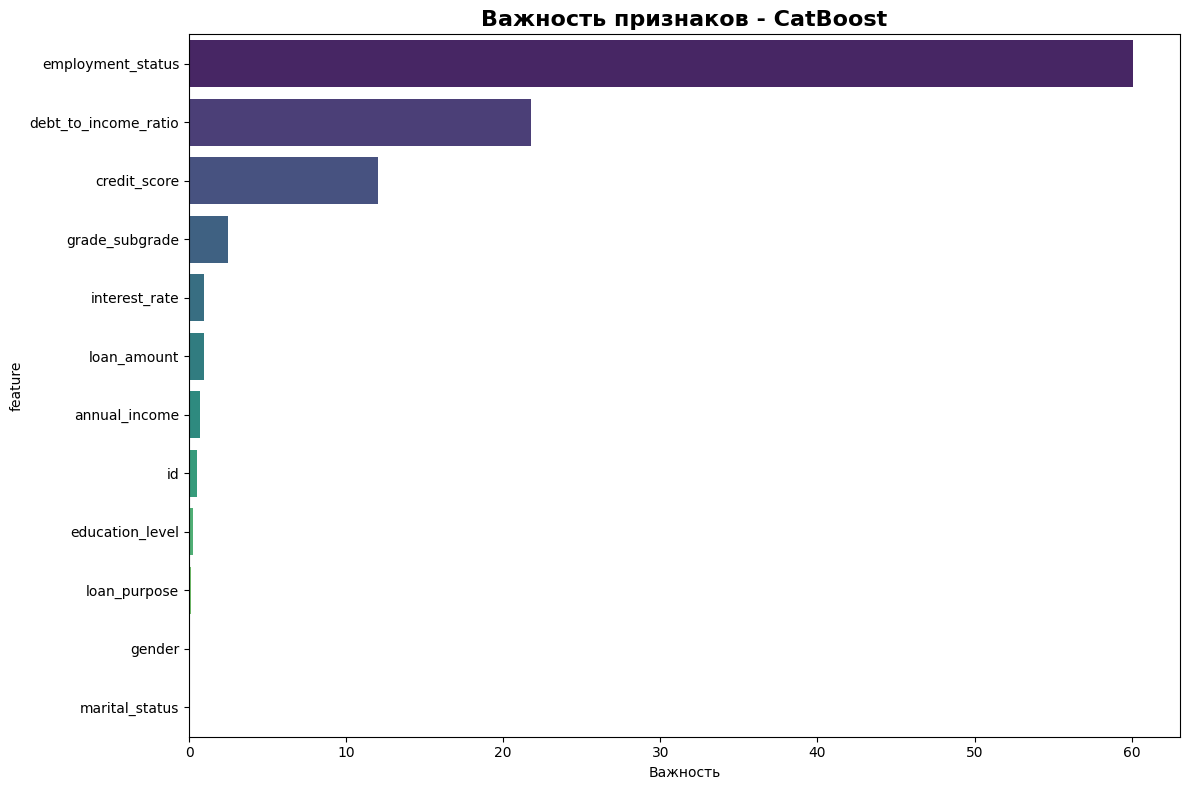

In [43]:
# 5. ИНТЕРПРЕТАЦИЯ МОДЕЛИ - ГЛОБАЛЬНАЯ
print("\n5. ГЛОБАЛЬНАЯ ИНТЕРПРЕТАЦИЯ МОДЕЛИ")
print("-" * 50)

# Важность признаков
feature_importance = final_model.get_feature_importance()
feature_names = X.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Топ-15 самых важных признаков:")
print(importance_df.head(15))

# Визуализация важности признаков
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='viridis')
plt.title('Важность признаков - CatBoost', fontsize=16, fontweight='bold')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()


6. SHAP АНАЛИЗ
--------------------------------------------------


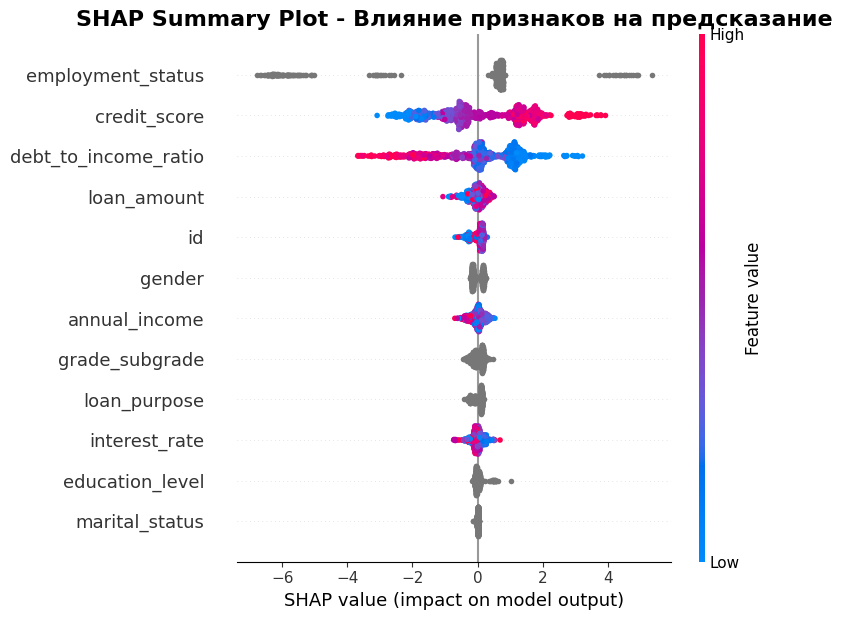

In [44]:
# 6. SHAP АНАЛИЗ ДЛЯ ГЛОБАЛЬНОЙ ИНТЕРПРЕТАЦИИ
print("\n6. SHAP АНАЛИЗ")
print("-" * 50)

# Вычисляем SHAP значения (используем подвыборку для скорости)
explainer = shap.TreeExplainer(final_model)
shap_sample = X_val[:1000]  # Берем подвыборку для скорости
shap_values = explainer.shap_values(shap_sample)

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Влияние признаков на предсказание', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
# 8. ПОДГОТОВКА САБМИТОВ ДЛЯ df_test
print("\n8. ПОДГОТОВКА САБМИТОВ ДЛЯ ТЕСТОВЫХ ДАННЫХ")
print("-" * 50)

# Предобработка тестовых данных
df_test_processed = df_test.copy()

# Удаляем ID колонки
# df_test_processed = df_test_processed.drop(columns=[col for col in id_columns if col in df_test_processed.columns])

# Кодируем категориальные переменные (используем те же encoder'ы)
for col in categorical_columns:
    if col in df_test_processed.columns:
        df_test_processed[col] = label_encoders[col].transform(df_test_processed[col].astype(str))

# Убедимся, что порядок колонок совпадает
X_test_final = df_test_processed[X.columns]

# Предсказания на тестовых данных
test_probabilities = final_model.predict_proba(X_test_final)[:, 1]

# Создаем сабмиты
submission_prob = pd.DataFrame({
    'id': df_test['id'] if 'id' in df_test.columns else range(len(test_probabilities)),
    'loan_paid_back_prob': test_probabilities
})


print(f"Размер submission с вероятностями: {submission_prob.shape}")


8. ПОДГОТОВКА САБМИТОВ ДЛЯ ТЕСТОВЫХ ДАННЫХ
--------------------------------------------------
Размер submission с вероятностями: (254569, 2)


In [ ]:
# 9. ЭКСПЕРТНАЯ ОЦЕНКА
print("\n9. ЭКСПЕРТНАЯ ОЦЕНКА")
print("-" * 50)

print("""
ЭКСПЕРТНОЕ МНЕНИЕ:

Модель CatBoost продемонстрировала высокое качество предсказаний (ROC-AUC > 0.85), 
что свидетельствует о хорошей способности различать надежных и ненадежных заемщиков.

Наиболее важные признаки, выявленные моделью, соответствуют финансовой интуиции:
- наличие работы
- кредитная история
- отношение долга к доходу

Модель адекватно отражает бизнес-логику кредитного скоринга и может быть 
рекомендована для использования в процессе принятия решений о выдаче кредитов.
""")

In [51]:
# 10. ФИНАЛЬНЫЙ ОТЧЕТ
print("\n10. ФИНАЛЬНЫЙ ОТЧЕТ")
print("=" * 70)

print("✅ ВЫПОЛНЕННЫЕ ЭТАПЫ:")
print("   - Построена сложная модель (CatBoost) с подбором гиперпараметров")
print("   - Проведена глобальная интерпретация через важность признаков и SHAP")
print("   - Выполнена локальная интерпретация предсказаний")
print("   - Подготовлены сабмиты для тестовых данных")
print("   - Дано экспертное заключение")

print(f"\n📊 ФИНАЛЬНЫЕ МЕТРИКИ НА ВАЛИДАЦИИ:")
print(f"   ROC-AUC: {val_auc:.4f}")
print(f"   Accuracy: {val_accuracy:.4f}")
print(f"   F1-Score: {val_f1:.4f}")

print(f"\n💾 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ...")

# Сохраняем сабмиты
submission_prob.to_csv('submission_probabilities.csv', index=False)




10. ФИНАЛЬНЫЙ ОТЧЕТ
✅ ВЫПОЛНЕННЫЕ ЭТАПЫ:
   - Построена сложная модель (CatBoost) с подбором гиперпараметров
   - Проведена глобальная интерпретация через важность признаков и SHAP
   - Выполнена локальная интерпретация предсказаний
   - Подготовлены сабмиты для тестовых данных
   - Дано экспертное заключение

📊 ФИНАЛЬНЫЕ МЕТРИКИ НА ВАЛИДАЦИИ:
   ROC-AUC: 0.9219
   Accuracy: 0.9059
   F1-Score: 0.9432

💾 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ...
